In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_samples
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import os
os.getcwd()

'c:\\Users\\Bruno Abello\\Desktop\\Personal-projects\\Proyectos de Astronomía\\Laboratorio 4'

In [2]:
df = pd.read_csv("dataset_porcionado(in).csv").dropna(subset='pmra') # full gaia sample for one cluster
df = df.dropna(subset=['ra', 'dec', 'pmra','pmdec','parallax','bp_rp','phot_g_mean_mag'])
df.info(), df.columns

<class 'pandas.DataFrame'>
Index: 342356 entries, 0 to 365869
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0.1               342356 non-null  int64  
 1   Unnamed: 0                 342356 non-null  int64  
 2   source_id                  342356 non-null  int64  
 3   ra                         342356 non-null  float64
 4   dec                        342356 non-null  float64
 5   parallax                   342356 non-null  float64
 6   pmra                       342356 non-null  float64
 7   pmdec                      342356 non-null  float64
 8   ruwe                       342356 non-null  float64
 9   phot_g_mean_mag            342356 non-null  float64
 10  bp_rp                      342356 non-null  float64
 11  radial_velocity            164635 non-null  float64
 12  ra_error                   342356 non-null  float64
 13  dec_error                  342356 non-null  f

(None,
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'source_id', 'ra', 'dec', 'parallax',
        'pmra', 'pmdec', 'ruwe', 'phot_g_mean_mag', 'bp_rp', 'radial_velocity',
        'ra_error', 'dec_error', 'pmra_error', 'pmdec_error', 'parallax_error',
        'visibility_periods_used', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
        'nu_eff_used_in_astrometry', 'pseudocolour', 'ecl_lat',
        'astrometric_params_solved', 'zp', 'fidelity_v2', 'parallax_',
        'parallax_over_error', 'cell_id'],
       dtype='str'))

In [3]:

# features derivadas
df["dist_pc"] = 1000 / df["parallax"]
df["parallax_over_error"] = df["parallax_error"] / df["parallax"]

# filtro global (opcional pero recomendable)
df = df[df["parallax_over_error"] <= 0.1]

print("Total estrellas:", len(df))
print("Total estrellas inicial:", len(df))
print("Índices únicos:", df.index.nunique())

Total estrellas: 342356
Total estrellas inicial: 342356
Índices únicos: 342356


In [4]:
clustering_on = ['pmra','pmdec','dist_pc']


total_input = 0
total_processed = 0
unique_ids = set()

results = []

  0%|          | 0/64 [00:00<?, ?it/s]


Cell 1
N estrellas: 1461
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 2
N estrellas: 3967
N clusters encontrados: 2


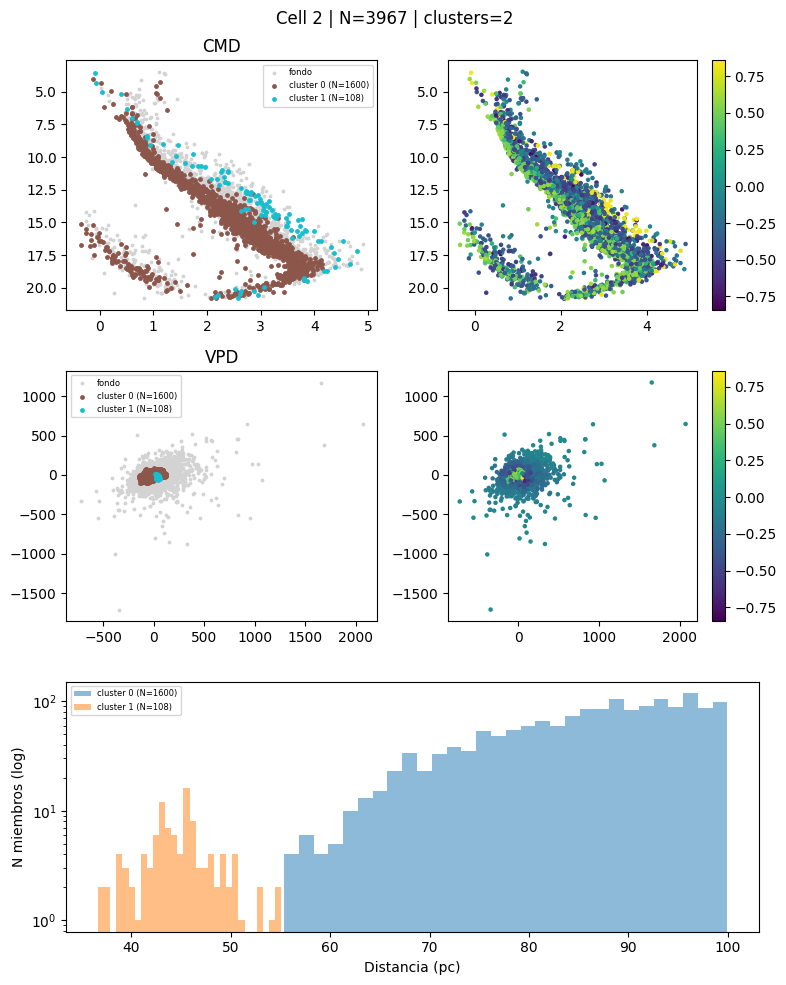

  3%|▎         | 2/64 [00:00<00:28,  2.20it/s]


Cell 3
N estrellas: 5716
N clusters encontrados: 2


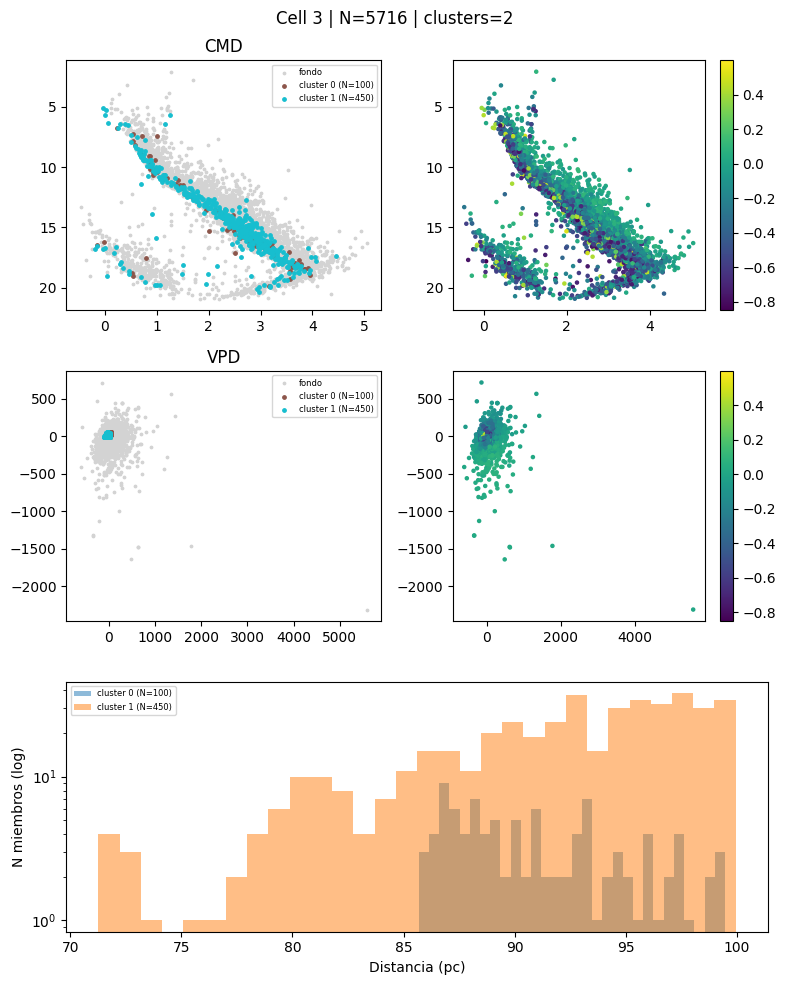

  5%|▍         | 3/64 [00:02<00:45,  1.34it/s]


Cell 4
N estrellas: 6519
N clusters encontrados: 2


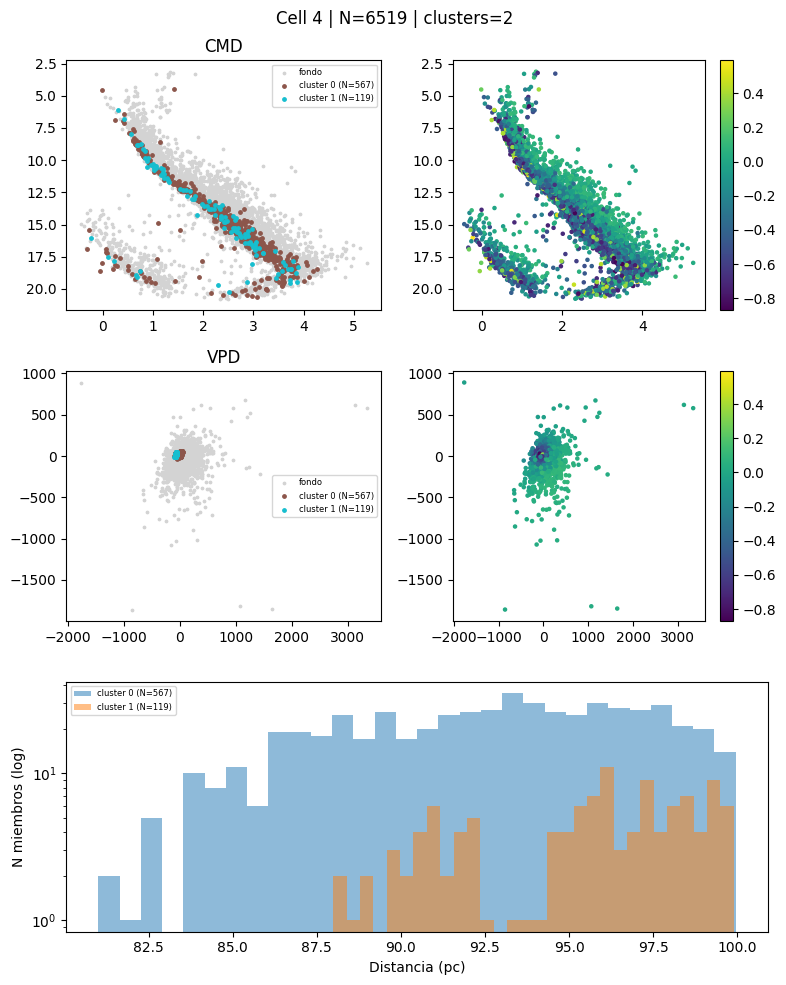

  6%|▋         | 4/64 [00:03<01:00,  1.00s/it]


Cell 5
N estrellas: 6638
N clusters encontrados: 2


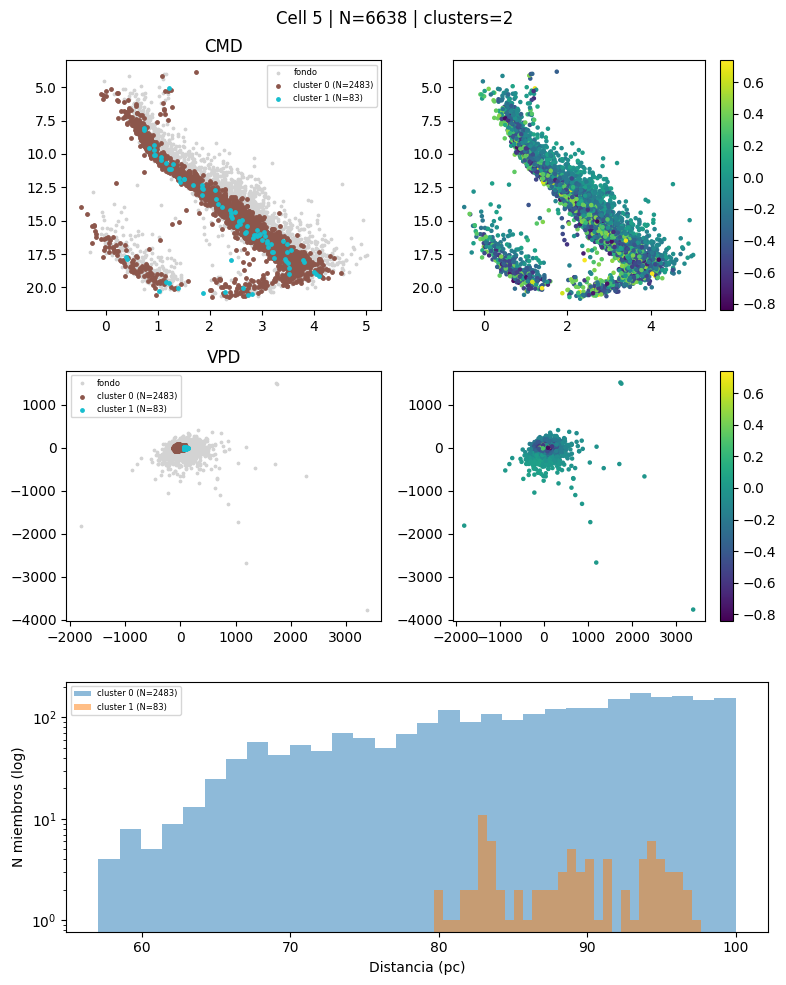

  8%|▊         | 5/64 [00:04<01:07,  1.14s/it]


Cell 6
N estrellas: 6059
N clusters encontrados: 2


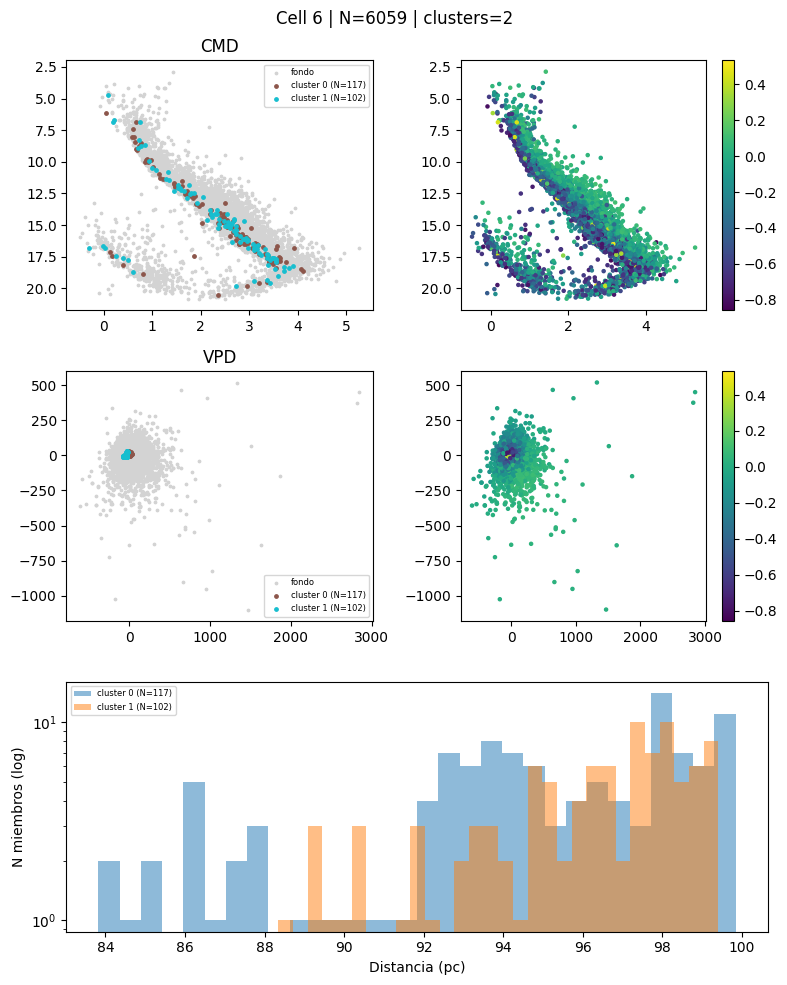

  9%|▉         | 6/64 [00:06<01:09,  1.19s/it]


Cell 7
N estrellas: 4307
N clusters encontrados: 2


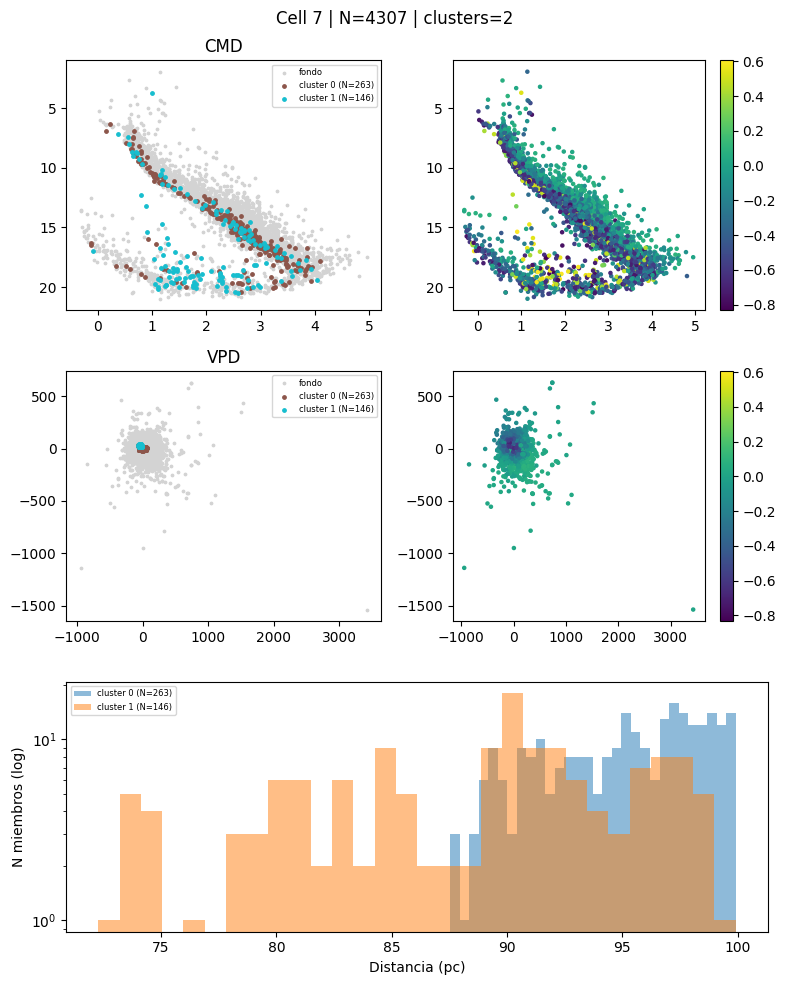

 16%|█▌        | 10/64 [00:07<00:26,  2.06it/s]


Cell 8
N estrellas: 1434
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 9
N estrellas: 1391
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 10
N estrellas: 3863
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 11
N estrellas: 5981
N clusters encontrados: 2


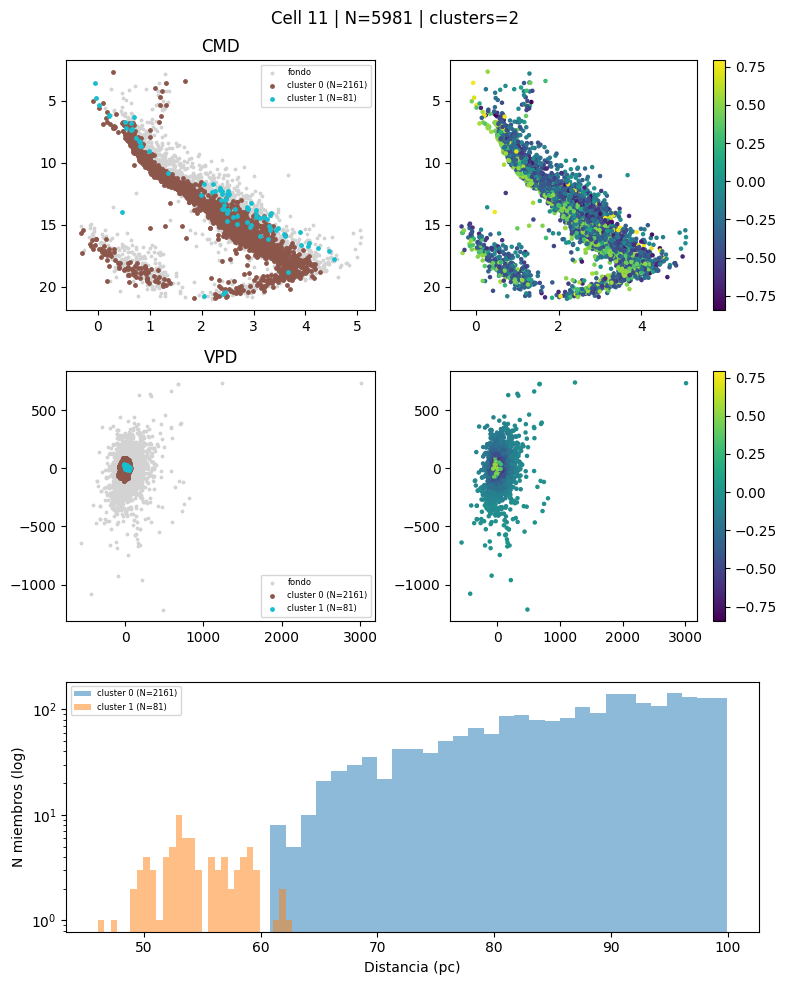

 17%|█▋        | 11/64 [00:08<00:34,  1.54it/s]


Cell 12
N estrellas: 7019


 20%|██        | 13/64 [00:08<00:23,  2.20it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 13
N estrellas: 5925
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 14
N estrellas: 5760
N clusters encontrados: 3


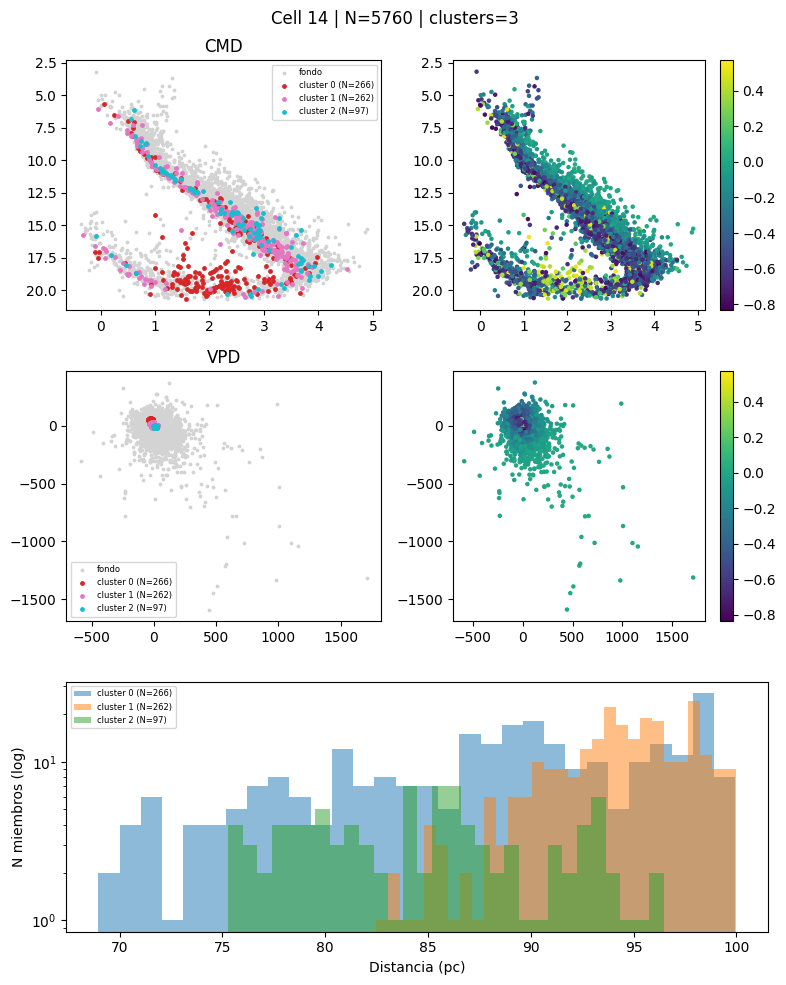

 22%|██▏       | 14/64 [00:10<00:32,  1.52it/s]


Cell 15
N estrellas: 4246
N clusters encontrados: 2


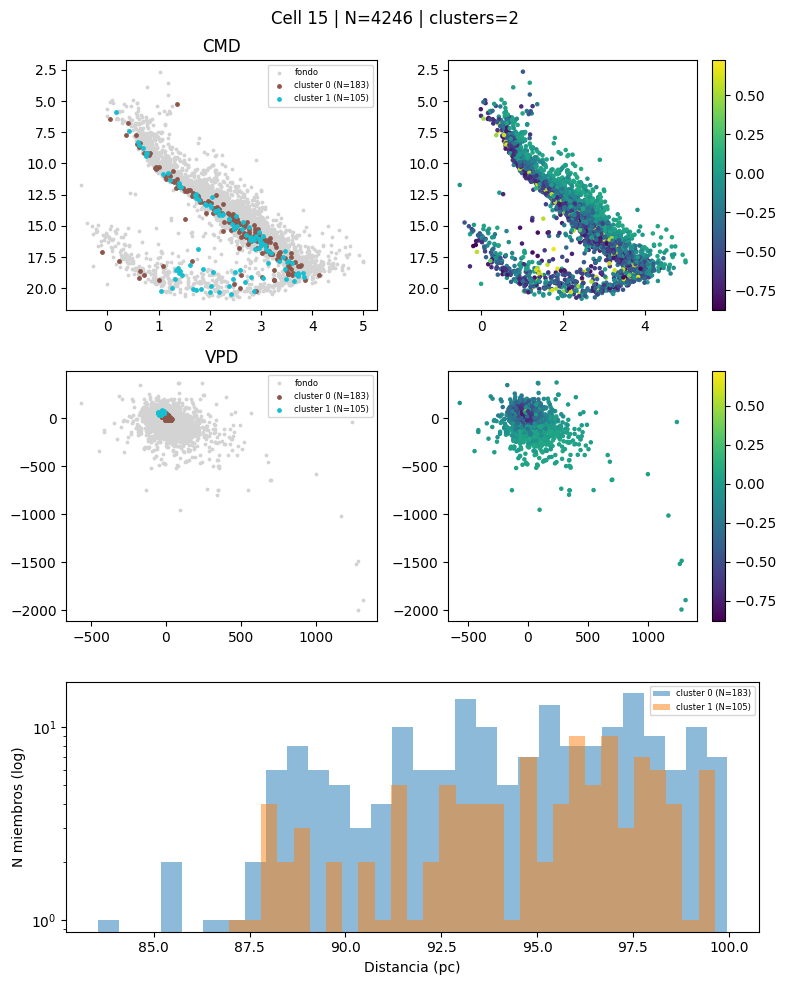

 28%|██▊       | 18/64 [00:11<00:16,  2.81it/s]


Cell 16
N estrellas: 1496
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 17
N estrellas: 1470
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 18
N estrellas: 4140
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 19
N estrellas: 7175


 30%|██▉       | 19/64 [00:11<00:14,  3.03it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 20
N estrellas: 7424
N clusters encontrados: 2


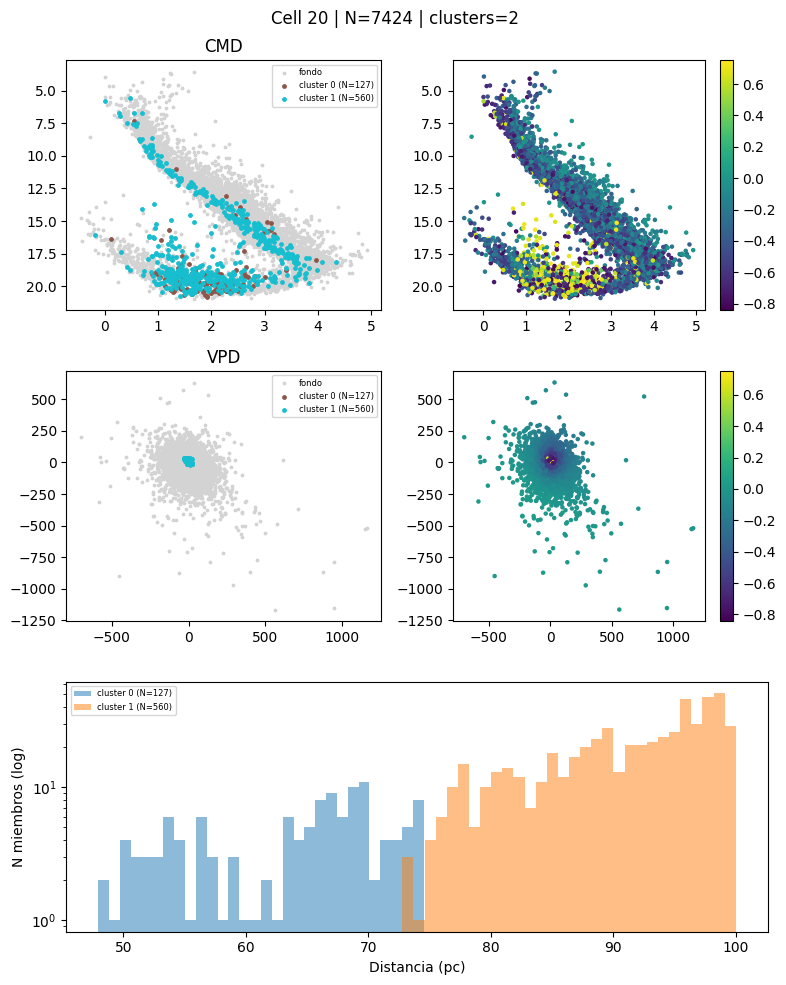

 31%|███▏      | 20/64 [00:13<00:27,  1.58it/s]


Cell 21
N estrellas: 6999
N clusters encontrados: 2


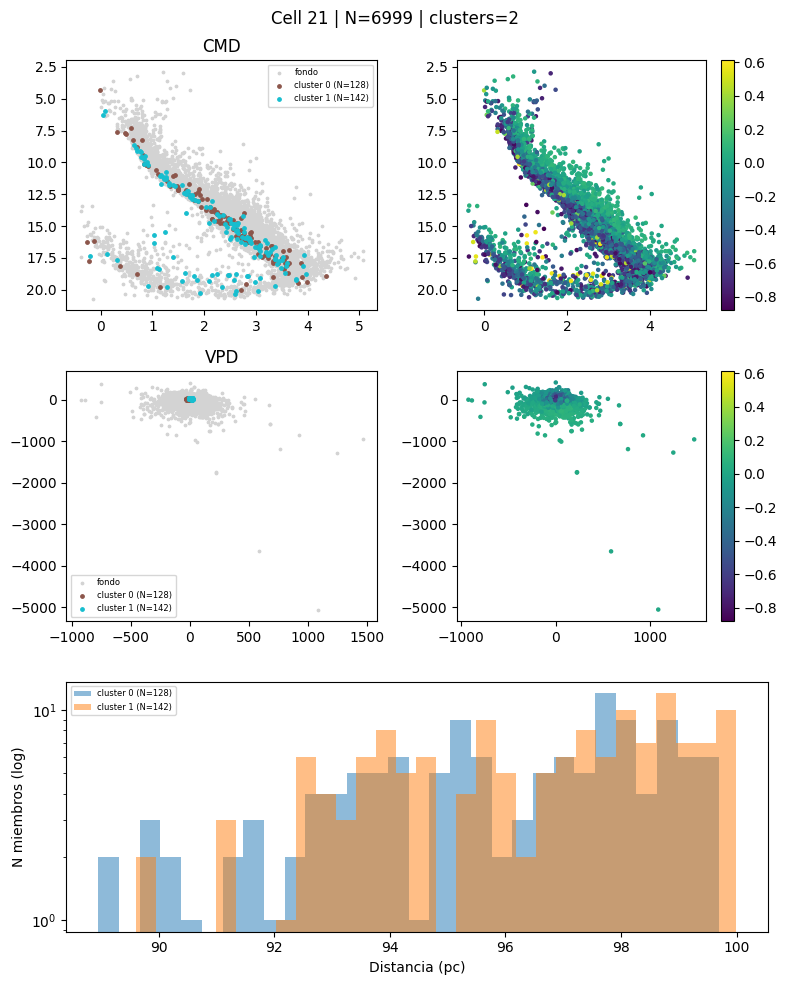

 33%|███▎      | 21/64 [00:14<00:36,  1.19it/s]


Cell 22
N estrellas: 5788
N clusters encontrados: 2


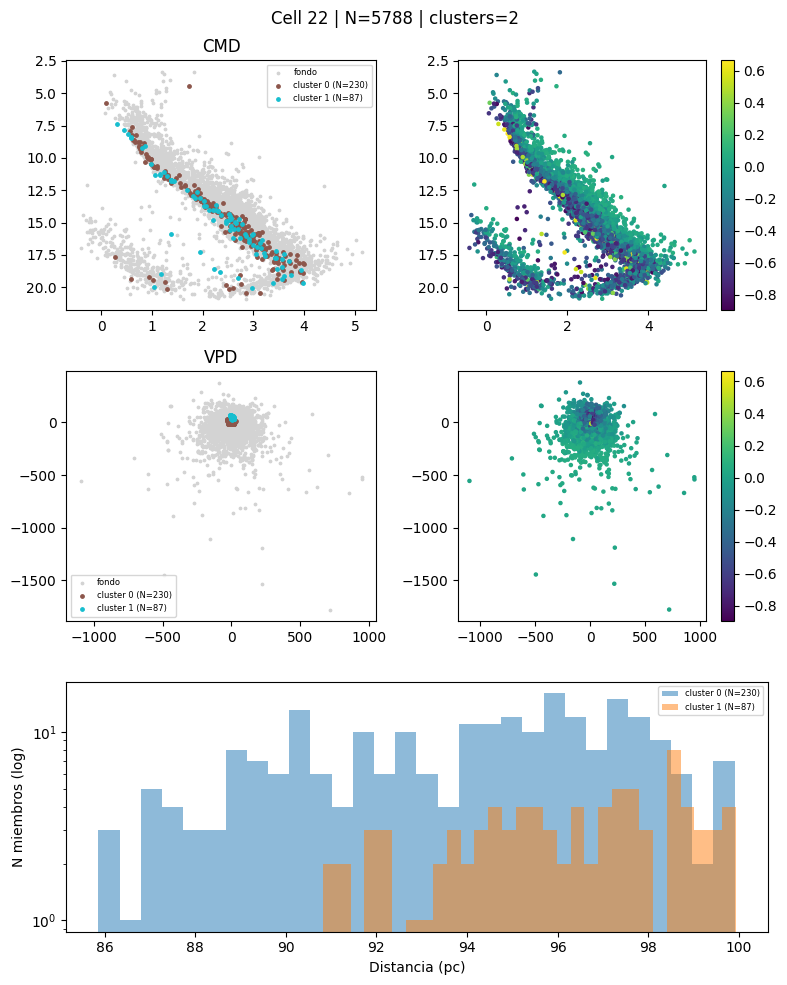

 34%|███▍      | 22/64 [00:15<00:39,  1.06it/s]


Cell 23
N estrellas: 3993
N clusters encontrados: 2


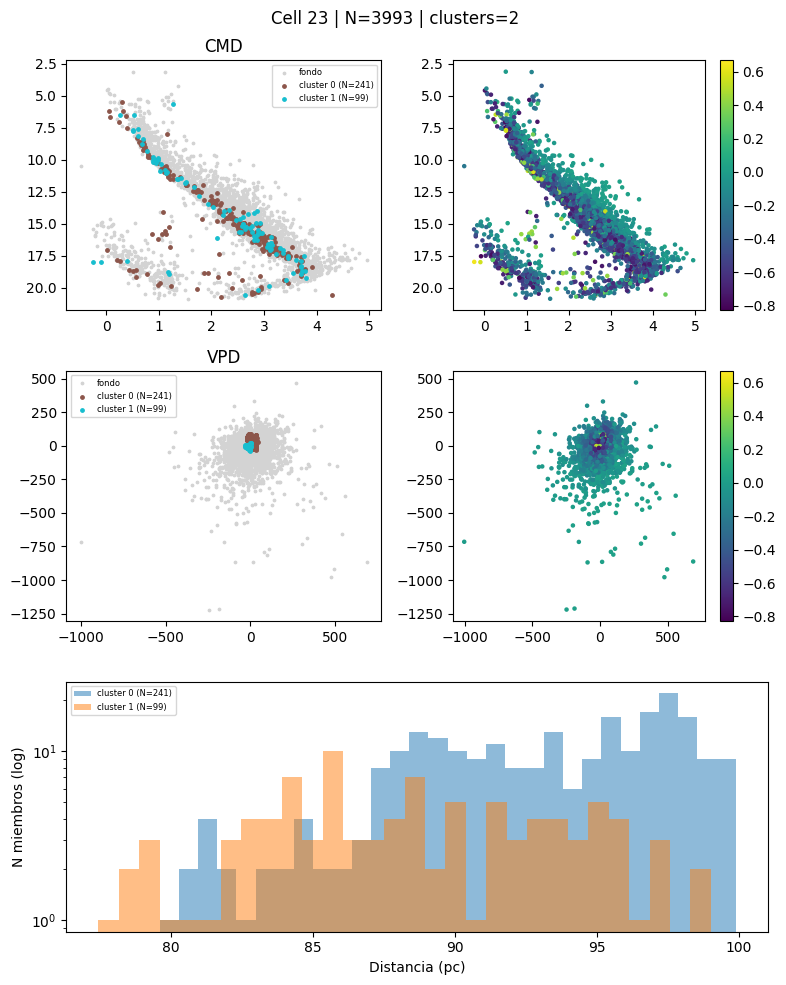

 36%|███▌      | 23/64 [00:16<00:38,  1.07it/s]


Cell 24
N estrellas: 1445
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 25
N estrellas: 1517
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 26
N estrellas: 4167
N clusters encontrados: 2


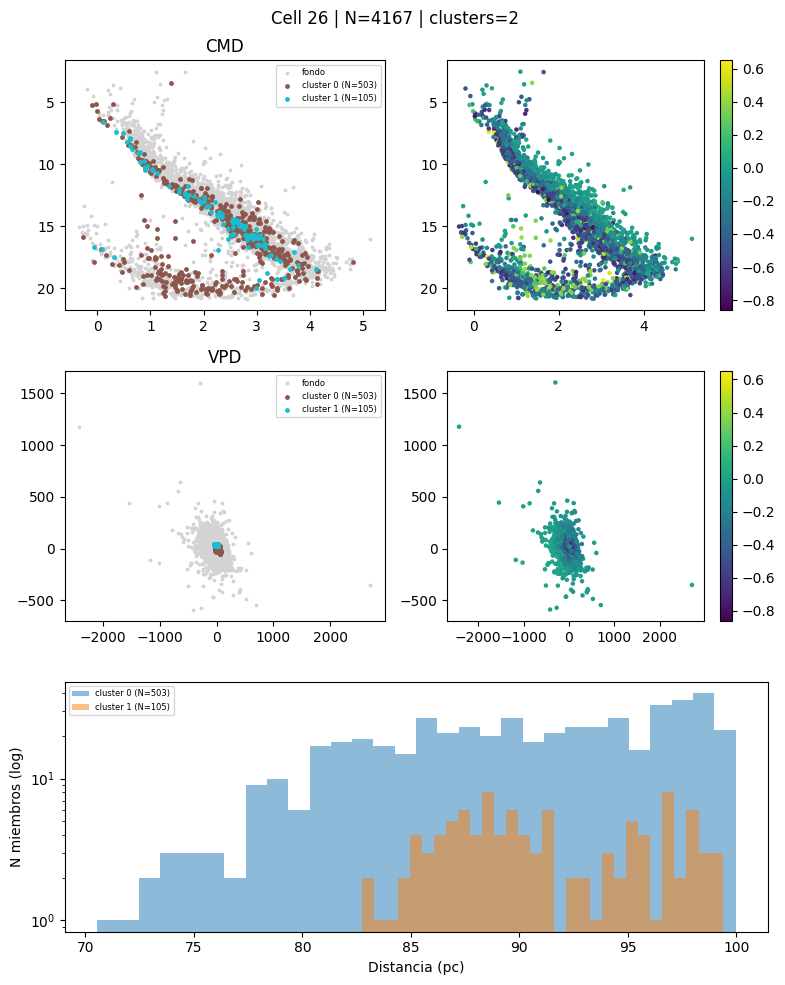

 42%|████▏     | 27/64 [00:17<00:19,  1.92it/s]


Cell 27
N estrellas: 6191
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 28
N estrellas: 6939
N clusters encontrados: 3


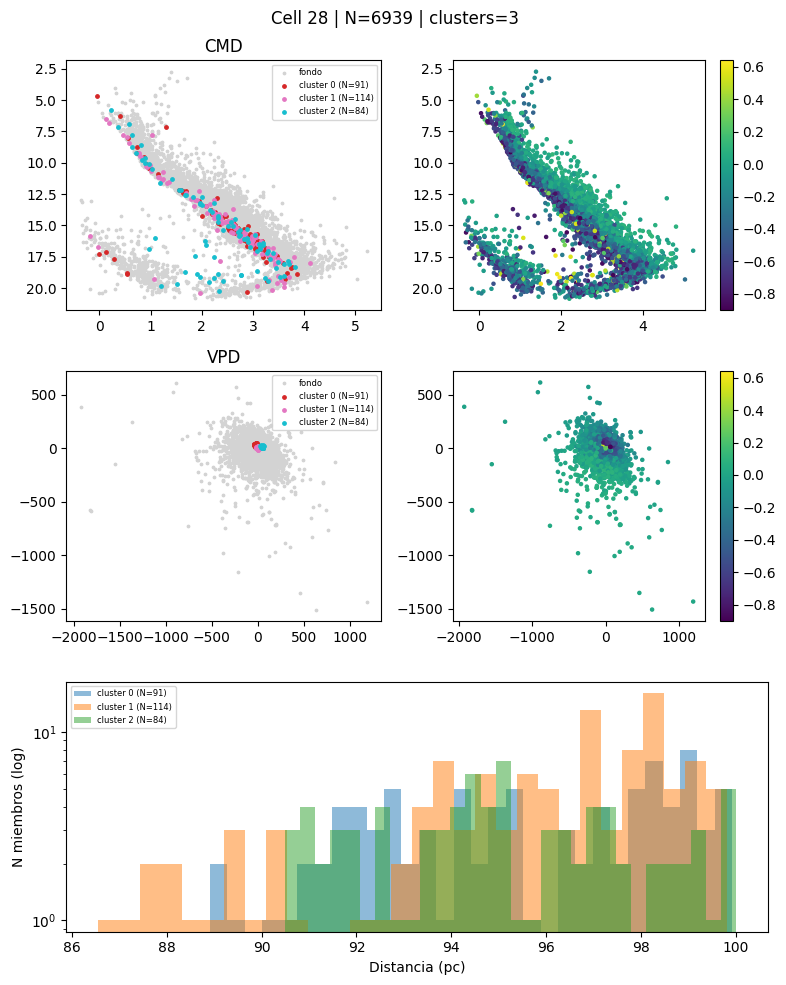

 44%|████▍     | 28/64 [00:19<00:26,  1.36it/s]


Cell 29
N estrellas: 6014
N clusters encontrados: 2


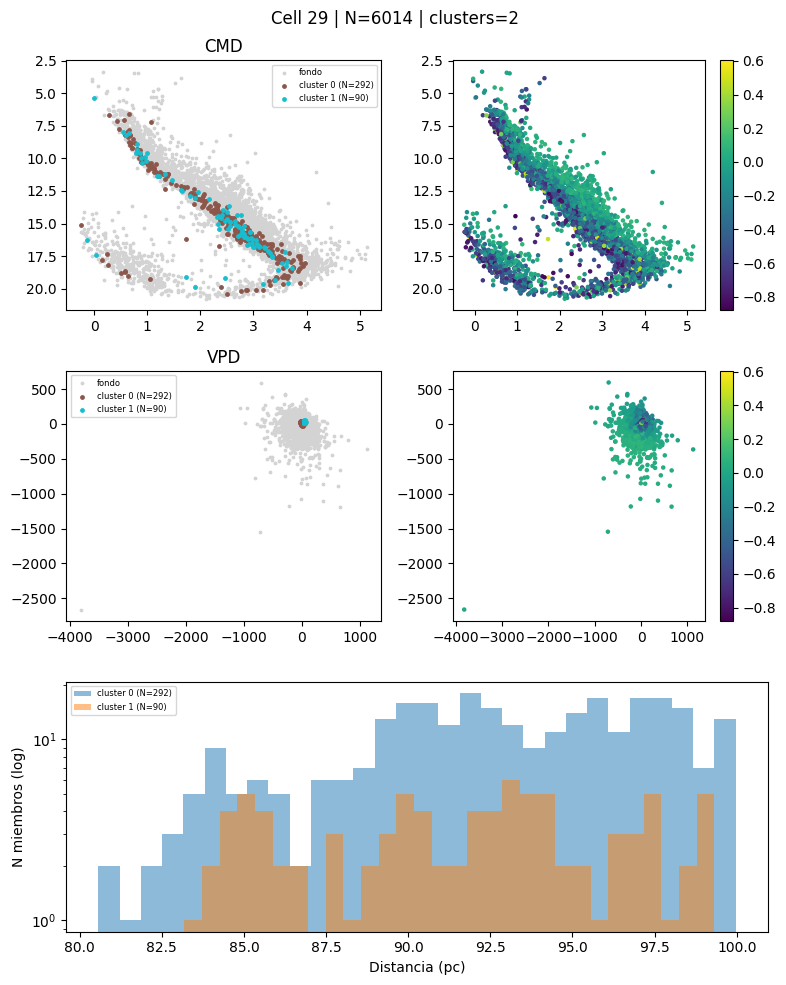

 47%|████▋     | 30/64 [00:20<00:22,  1.48it/s]


Cell 30
N estrellas: 4880
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 31
N estrellas: 3761
N clusters encontrados: 2


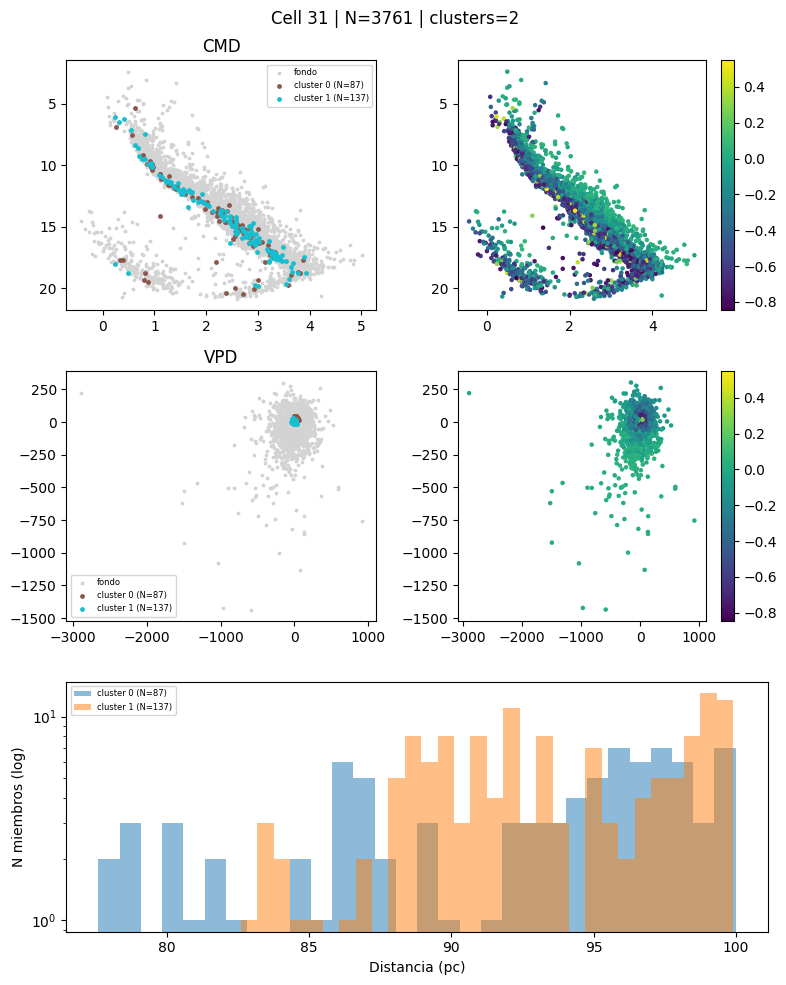

 48%|████▊     | 31/64 [00:21<00:23,  1.39it/s]


Cell 32
N estrellas: 1373
N clusters encontrados: 2


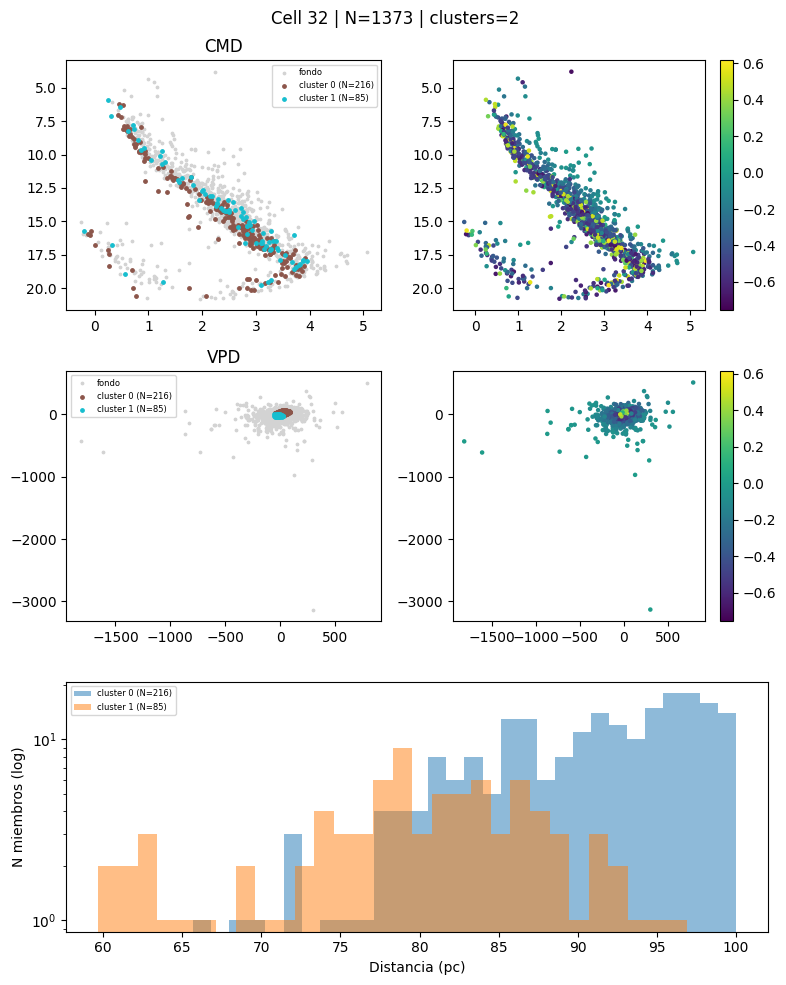

 50%|█████     | 32/64 [00:22<00:22,  1.42it/s]


Cell 33
N estrellas: 1514
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 34
N estrellas: 5863
N clusters encontrados: 2


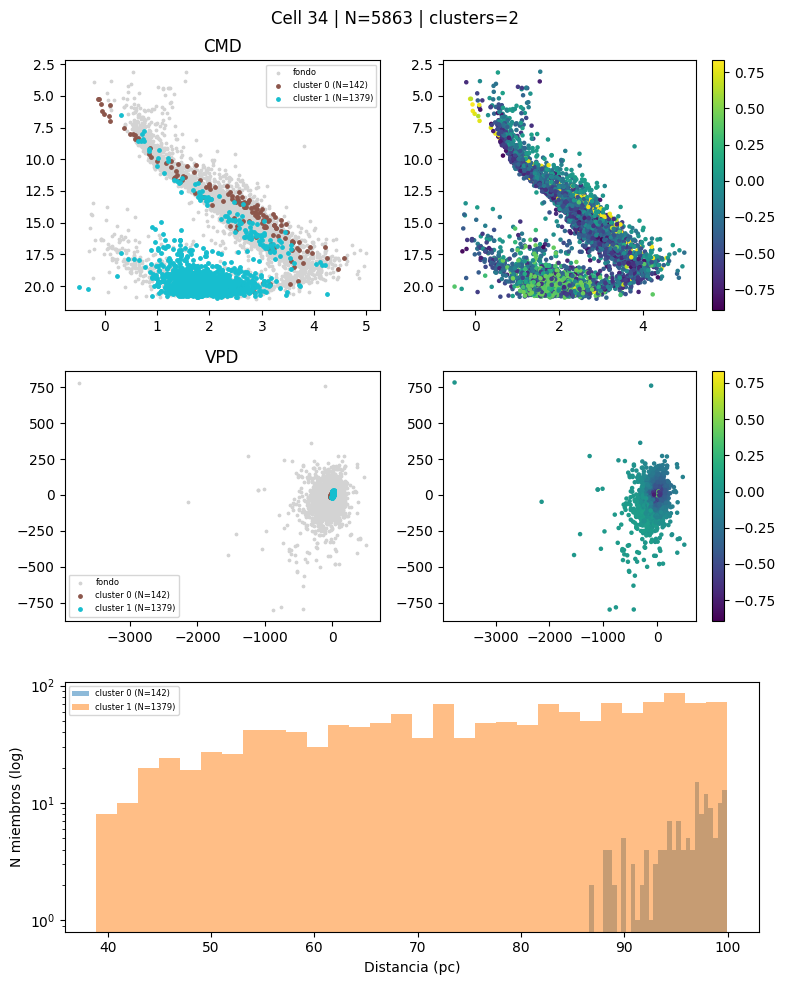

 53%|█████▎    | 34/64 [00:23<00:20,  1.49it/s]


Cell 35
N estrellas: 6379


 55%|█████▍    | 35/64 [00:23<00:16,  1.79it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 36
N estrellas: 7020


 58%|█████▊    | 37/64 [00:24<00:10,  2.56it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 37
N estrellas: 5630
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 38
N estrellas: 4170
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 39
N estrellas: 3935
N clusters encontrados: 2


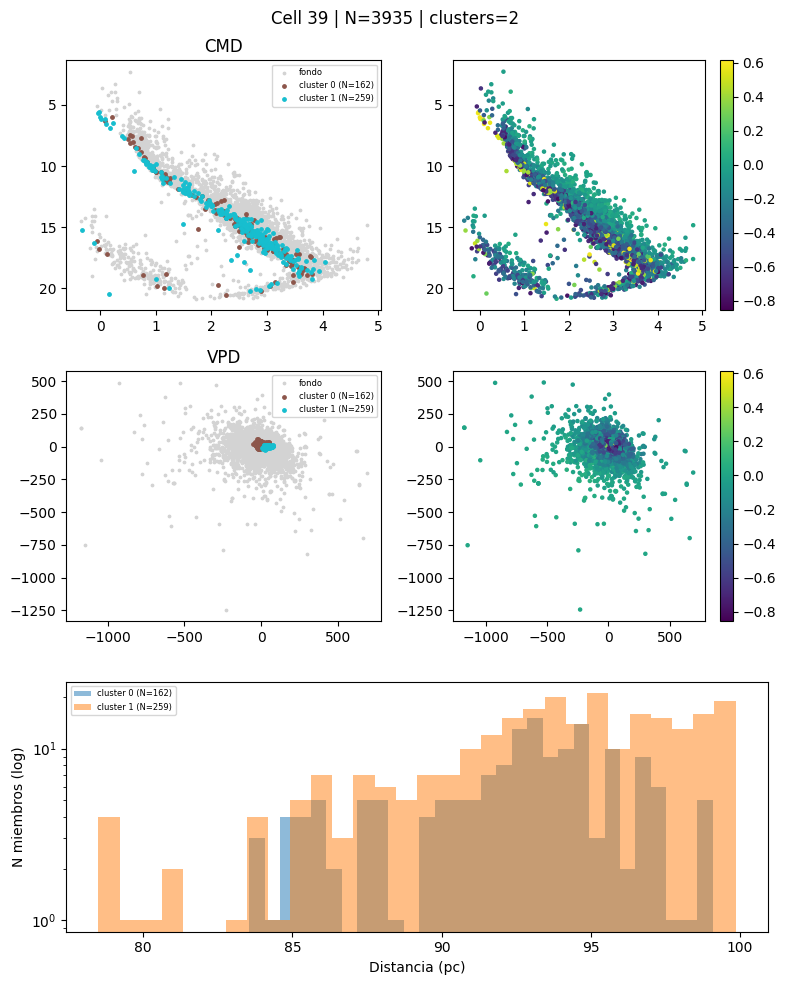

 61%|██████    | 39/64 [00:25<00:10,  2.31it/s]


Cell 40
N estrellas: 1387
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 41
N estrellas: 1607
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 42
N estrellas: 6578
N clusters encontrados: 2


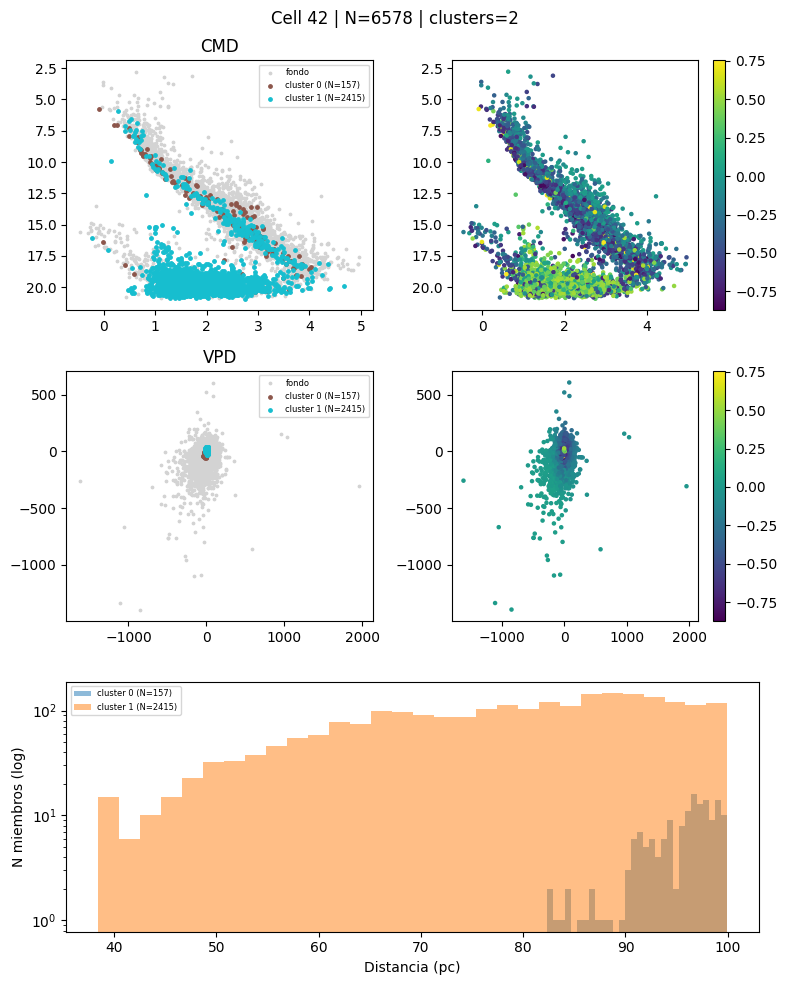

 66%|██████▌   | 42/64 [00:26<00:09,  2.22it/s]


Cell 43
N estrellas: 27671
N clusters encontrados: 3


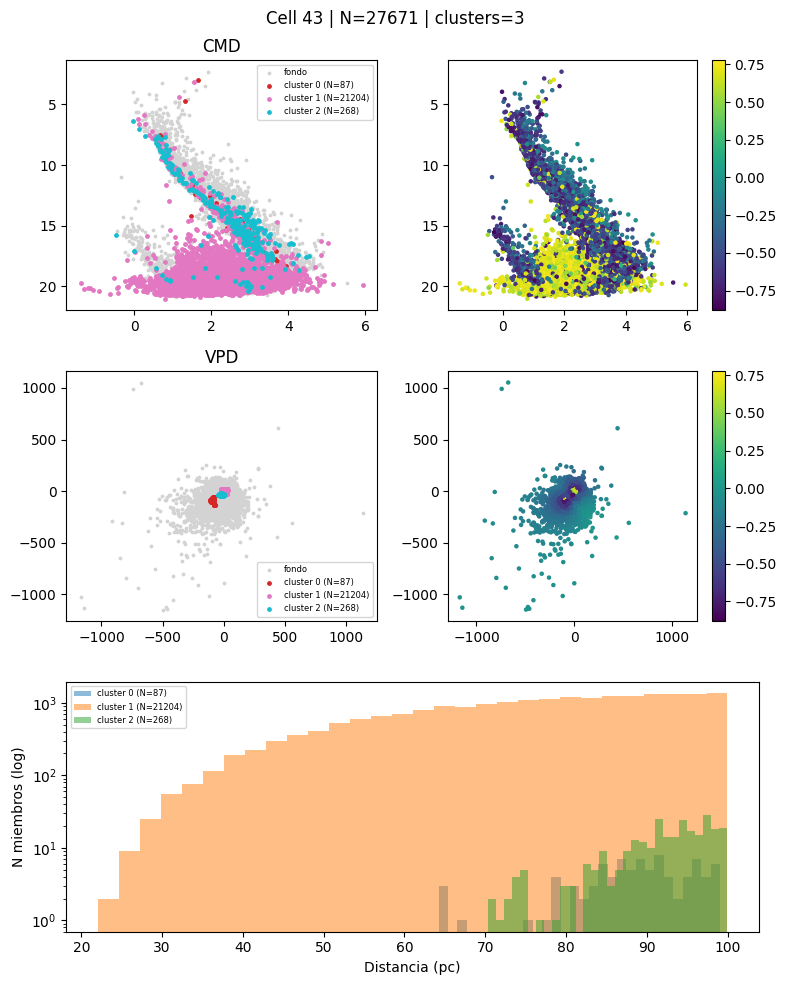

 67%|██████▋   | 43/64 [00:38<00:53,  2.55s/it]


Cell 44
N estrellas: 12000
N clusters encontrados: 3


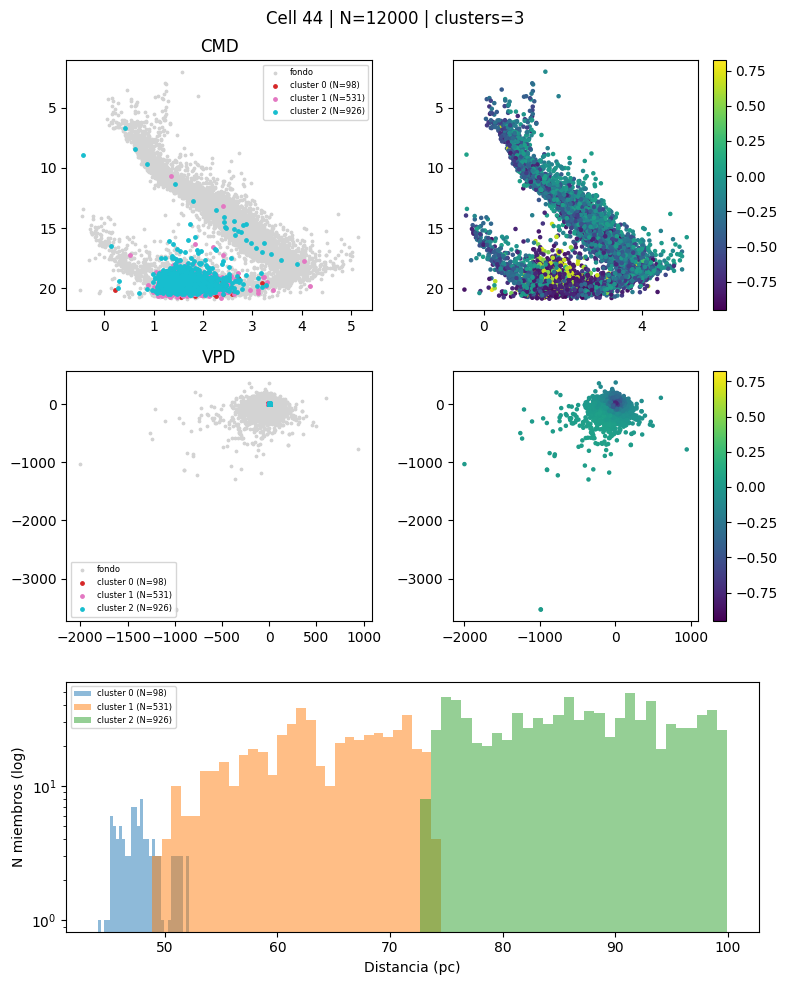

 69%|██████▉   | 44/64 [00:40<00:52,  2.60s/it]


Cell 45
N estrellas: 7295
N clusters encontrados: 2


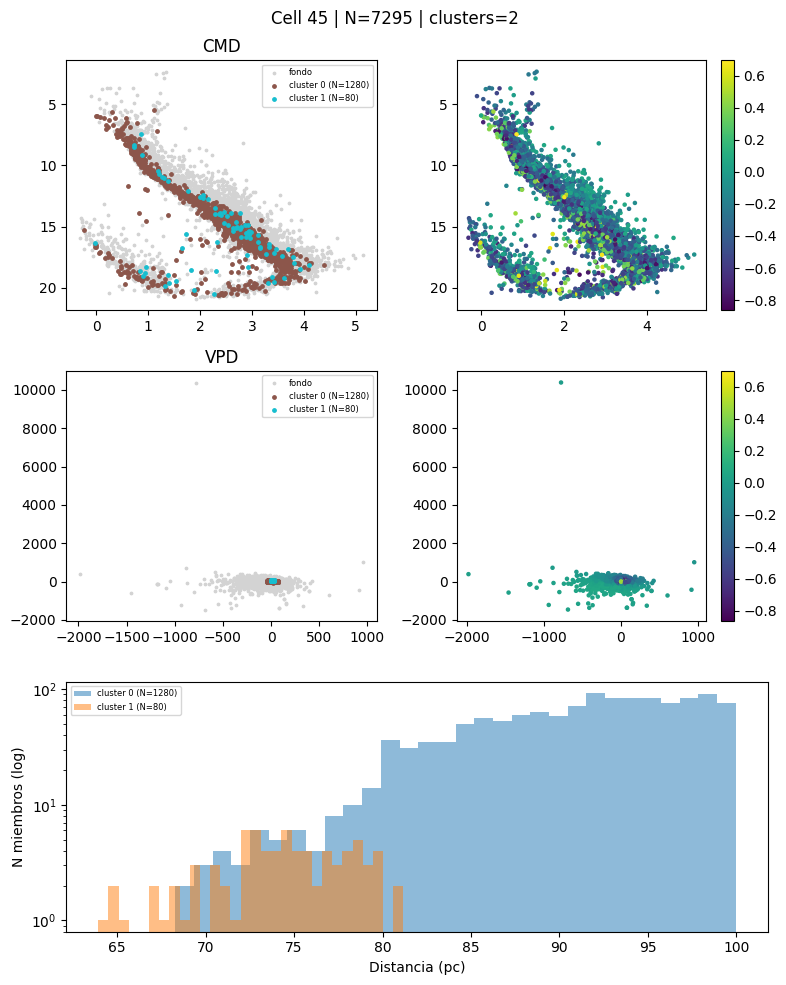

 72%|███████▏  | 46/64 [00:42<00:32,  1.82s/it]


Cell 46
N estrellas: 6094
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 47
N estrellas: 3946
N clusters encontrados: 2


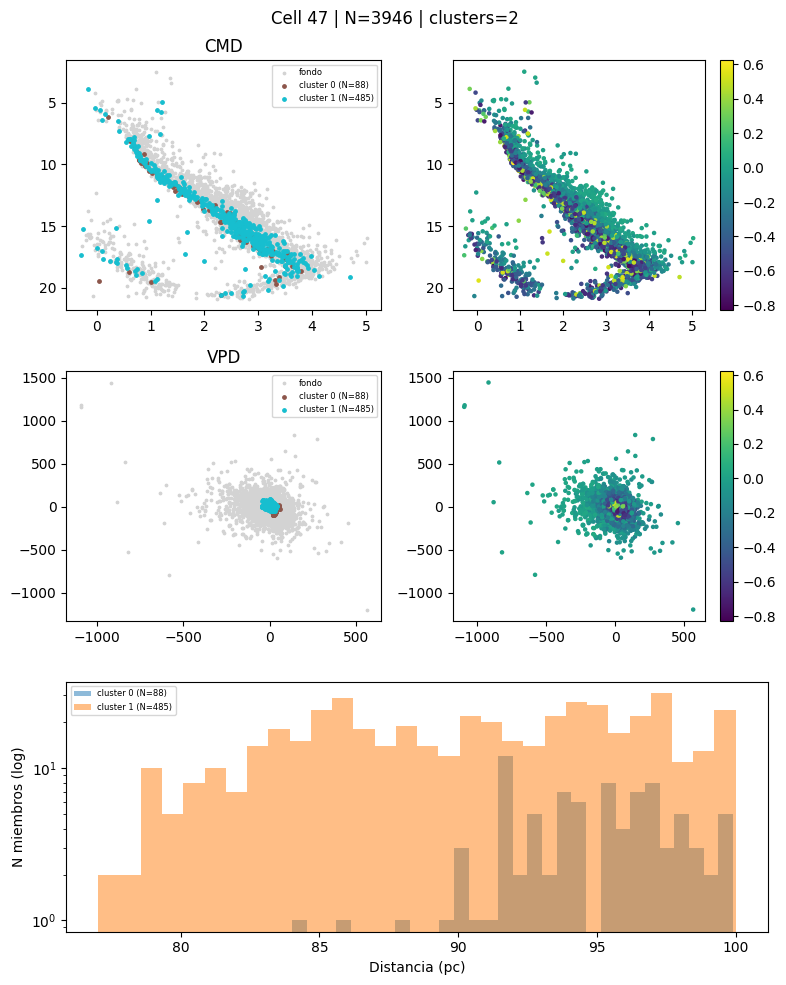

 78%|███████▊  | 50/64 [00:43<00:10,  1.30it/s]


Cell 48
N estrellas: 1491
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 49
N estrellas: 1543
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 50
N estrellas: 4338
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 51
N estrellas: 12516
N clusters encontrados: 3


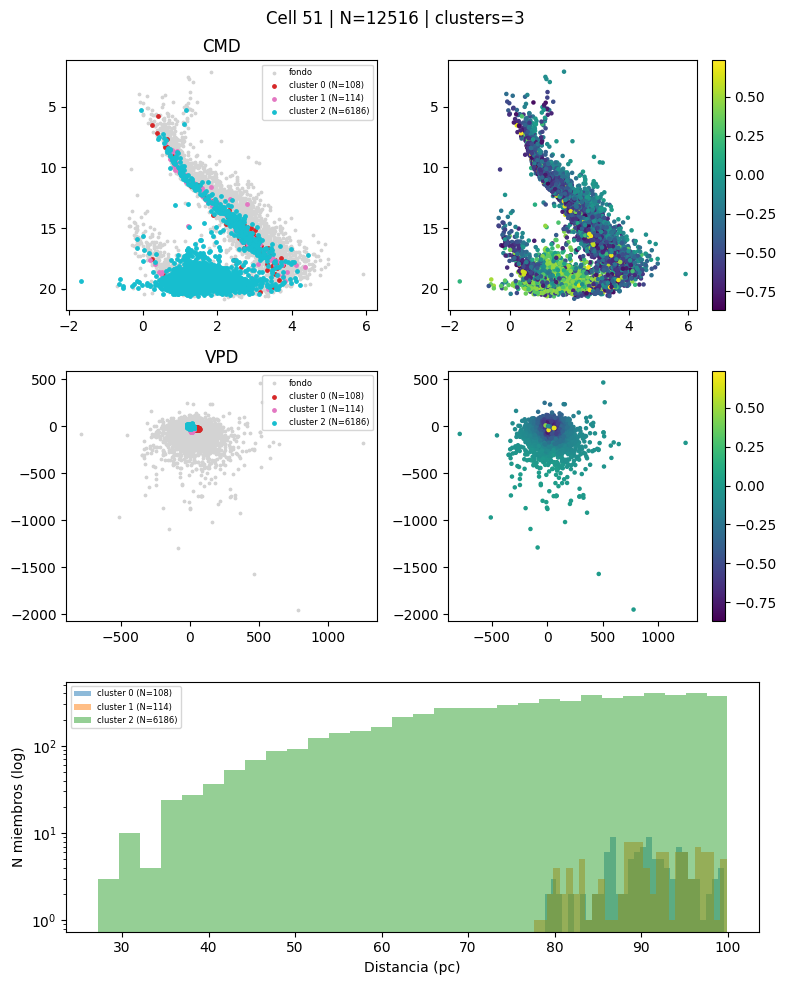

 80%|███████▉  | 51/64 [00:46<00:15,  1.22s/it]


Cell 52
N estrellas: 12219
N clusters encontrados: 2


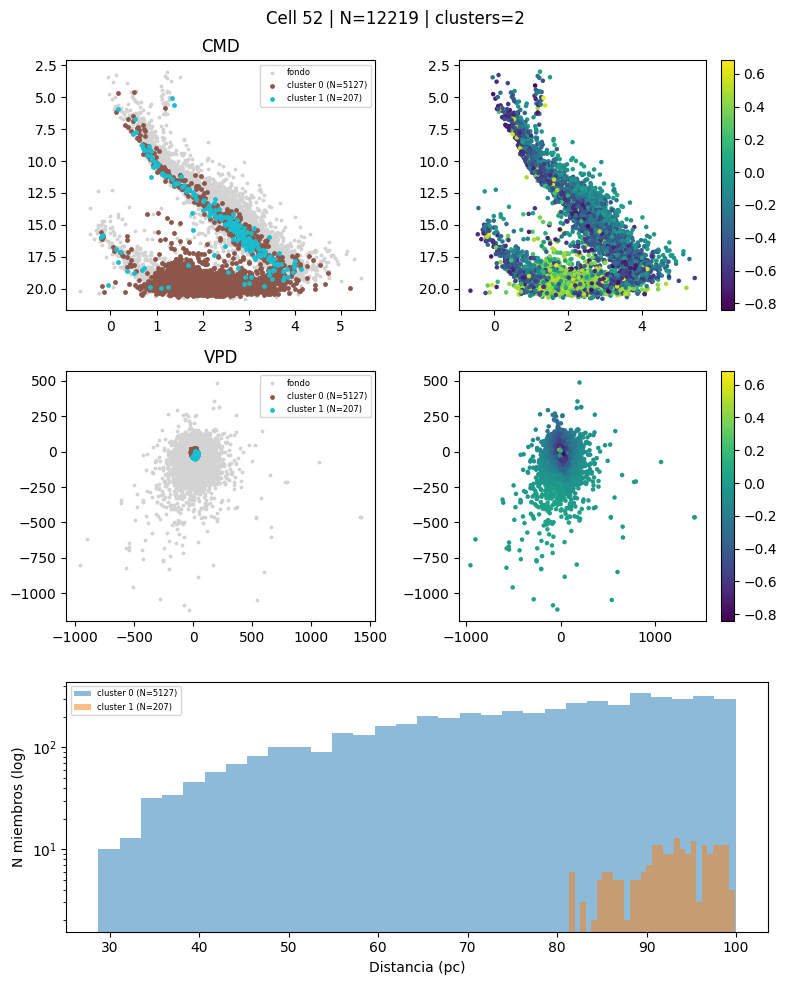

 81%|████████▏ | 52/64 [00:49<00:18,  1.58s/it]


Cell 53
N estrellas: 11638
N clusters encontrados: 2


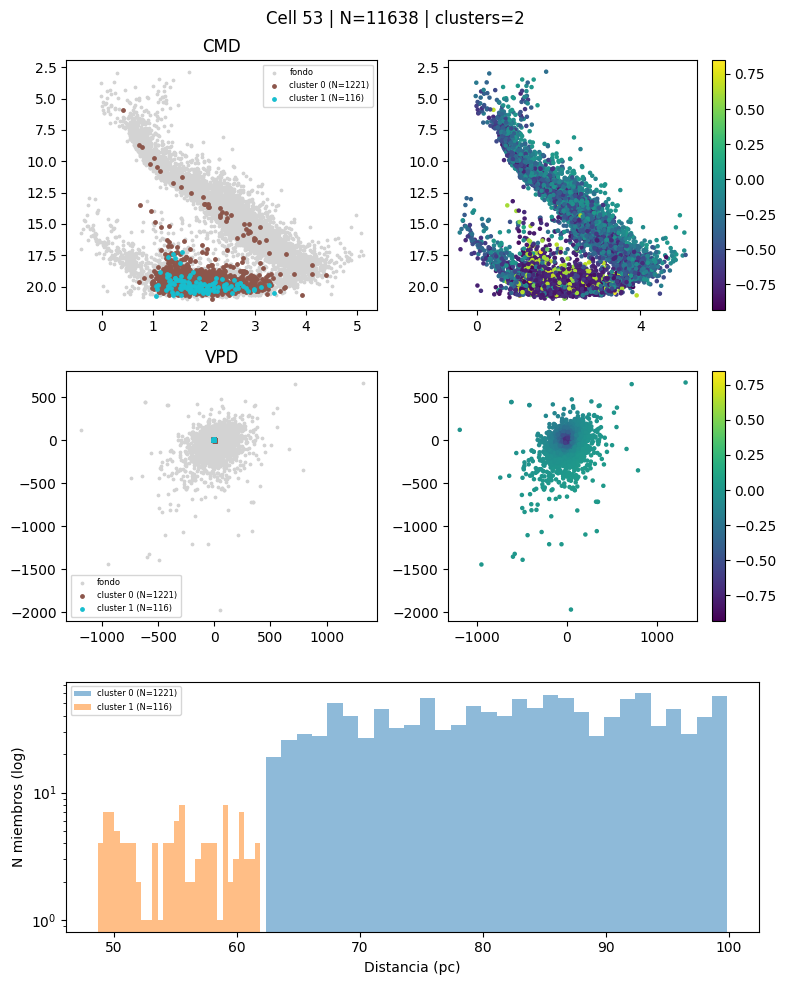

 83%|████████▎ | 53/64 [00:52<00:20,  1.85s/it]


Cell 54
N estrellas: 9276
N clusters encontrados: 3


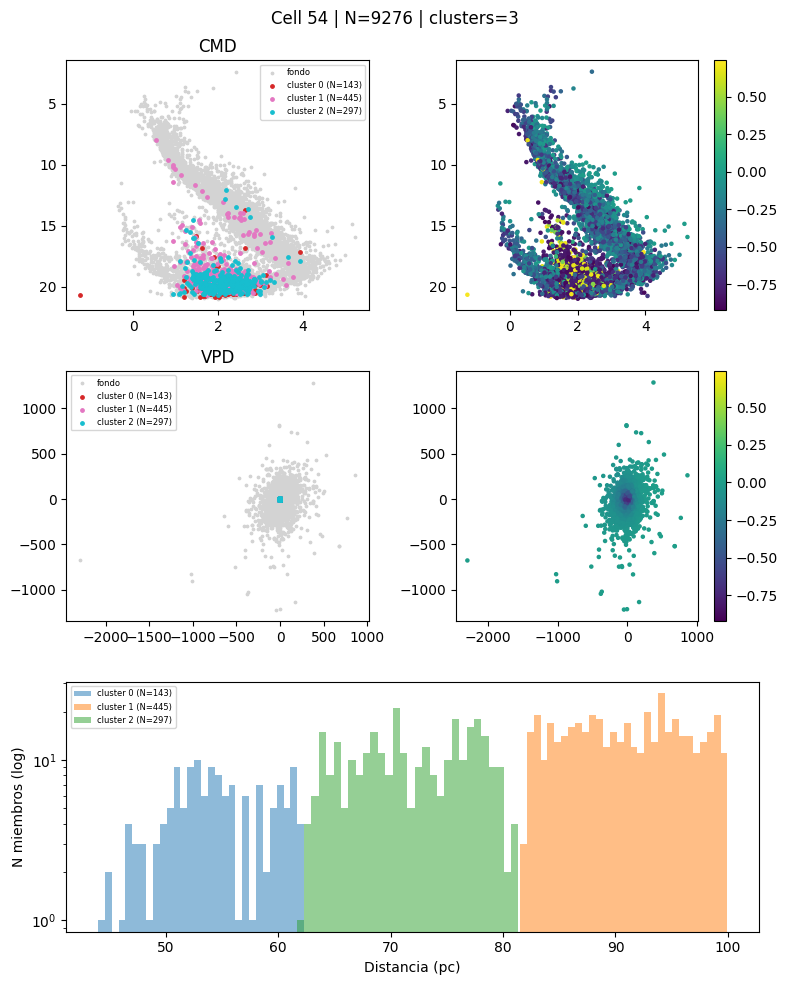

 88%|████████▊ | 56/64 [00:54<00:09,  1.13s/it]


Cell 55
N estrellas: 4167
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 56
N estrellas: 1421
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 57
N estrellas: 1433
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 58
N estrellas: 4040
N clusters encontrados: 0
Solo ruido, no se grafica

Cell 59
N estrellas: 5892


 92%|█████████▏| 59/64 [00:54<00:03,  1.57it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 60
N estrellas: 6982
N clusters encontrados: 2


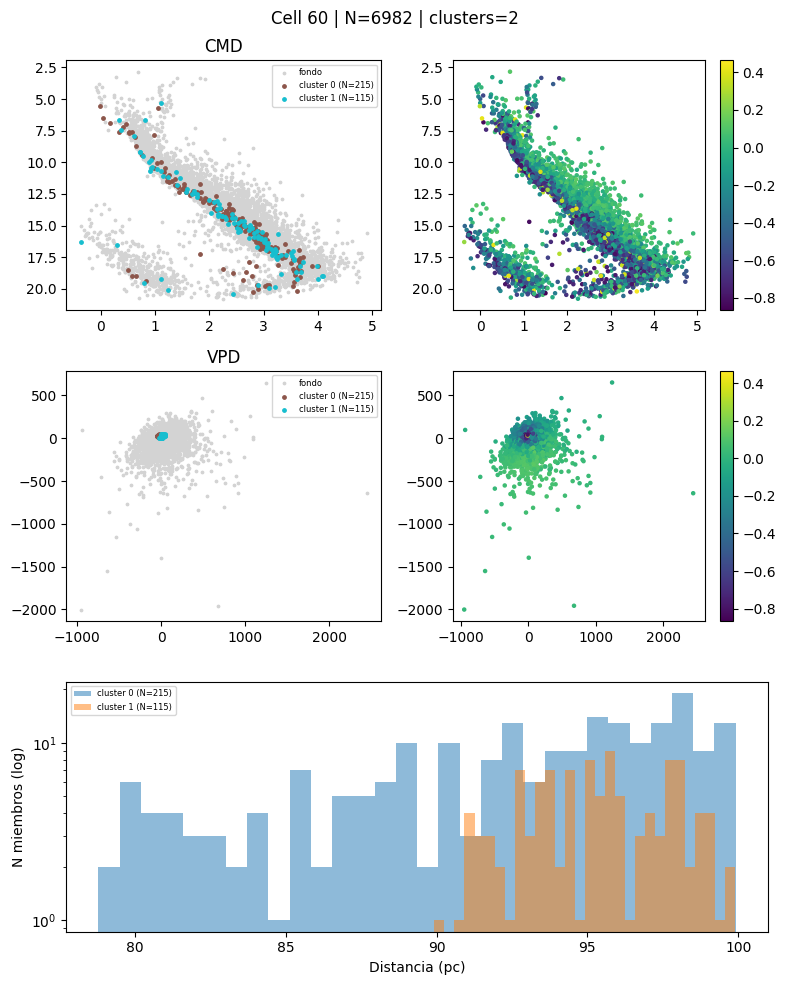

 94%|█████████▍| 60/64 [00:56<00:03,  1.27it/s]


Cell 61
N estrellas: 7011


 95%|█████████▌| 61/64 [00:56<00:02,  1.47it/s]

N clusters encontrados: 0
Solo ruido, no se grafica

Cell 62
N estrellas: 6341
N clusters encontrados: 2


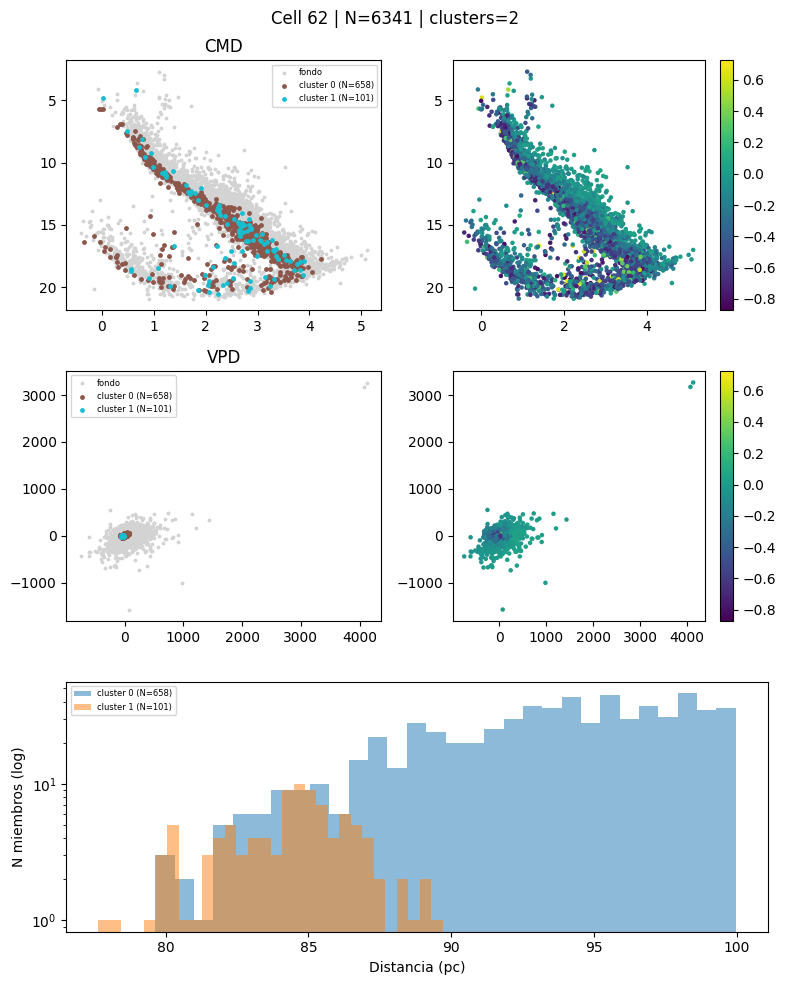

 97%|█████████▋| 62/64 [00:57<00:01,  1.22it/s]


Cell 63
N estrellas: 4381
N clusters encontrados: 2


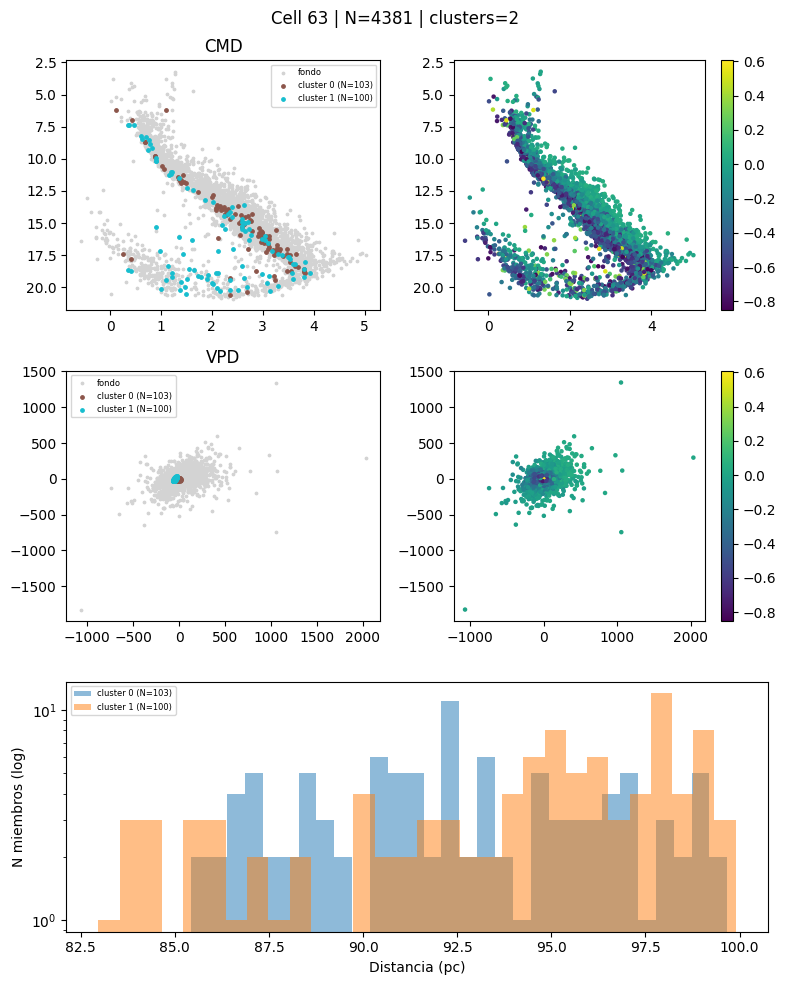

100%|██████████| 64/64 [00:58<00:00,  1.09it/s]


Cell 64
N estrellas: 1520
N clusters encontrados: 0
Solo ruido, no se grafica

CHECK GLOBAL
Total entrada (sumado): 684712
Total procesado (sumado): 684712
Total final filas: 684712
Total estrellas únicas procesadas: 342356
Índices únicos en df_final: 342356


In [6]:
for cell_id in tqdm(sorted(df["cell_id"].unique())):

    df_cell = df[df["cell_id"] == cell_id].copy()

    n_stars = len(df_cell)
    total_input += n_stars

    unique_ids.update(df_cell.index)

    print("\n==============================")
    print(f"Cell {cell_id}")
    print(f"N estrellas: {n_stars}")

    if n_stars < 30:
        print("Muy pocas estrellas, se omite")
        continue

    # ------------------
    # preparar datos
    # ------------------

    features = df_cell[['pmra','pmdec','dist_pc']]
    data_scaled = RobustScaler().fit_transform(features)

    # ------------------
    # HDBSCAN
    # ------------------

    hd = HDBSCAN(
        min_cluster_size=80,
        min_samples=5,
        metric='euclidean'
    ).fit(data_scaled)

    labels = hd.labels_
    df_cell["label_hb"] = labels

    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    print(f"N clusters encontrados: {n_clusters}")

    total_processed += len(df_cell)

    if n_clusters == 0:
        print("Solo ruido, no se grafica")
        results.append(df_cell)
        continue

    # ------------------
    # silhouette
    # ------------------

    if n_clusters > 1:
        sil = silhouette_samples(data_scaled, labels)
        df_cell["silhouette"] = sil
    else:
        df_cell["silhouette"] = np.nan

    # ------------------
    # centrar VPD
    # ------------------

    df_cell["pmra_rel"] = df_cell["pmra"] - df_cell["pmra"].median()
    df_cell["pmdec_rel"] = df_cell["pmdec"] - df_cell["pmdec"].median()

    # ------------------
    # colores
    # ------------------

    unique_labels = np.unique(labels)
    cmap = plt.cm.get_cmap('tab10', len(unique_labels))

    color_map = {
        lab: ('lightgray' if lab == -1 else cmap(i))
        for i, lab in enumerate(unique_labels)
    }

    # ------------------
    # tamaños de clusters
    # ------------------

    cluster_sizes = {
        lab: np.sum(df_cell["label_hb"] == lab)
        for lab in unique_labels if lab != -1
        }

    # ======================
    # FIGURA
    # ======================

    fig = plt.figure(figsize=(8,10))
    gs = fig.add_gridspec(3,2)

    ax_cmd = fig.add_subplot(gs[0,0])
    ax_cmd_sil = fig.add_subplot(gs[0,1])
    ax_vpd = fig.add_subplot(gs[1,0])
    ax_vpd_sil = fig.add_subplot(gs[1,1])
    ax_hist = fig.add_subplot(gs[2,:])

    # ======================
    # CMD fondo
    # ======================

    ax_cmd.scatter(df_cell["bp_rp"], df_cell["phot_g_mean_mag"],
               c='lightgray', s=3, label="fondo")

    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab

        ax_cmd.scatter(
            df_cell["bp_rp"][cond],
            df_cell["phot_g_mean_mag"][cond],
            s=6,
            color=color_map[lab],
            label=f"cluster {lab} (N={cluster_sizes[lab]})"
        )

    ax_cmd.invert_yaxis()
    ax_cmd.set_title("CMD")
    ax_cmd.legend(fontsize=6)

    # ======================
    # CMD silueta
    # ======================

    sc1 = ax_cmd_sil.scatter(
        df_cell["bp_rp"],
        df_cell["phot_g_mean_mag"],
        c=df_cell["silhouette"],
        cmap="viridis",
        s=5
    )

    ax_cmd_sil.invert_yaxis()
    fig.colorbar(sc1, ax=ax_cmd_sil)

    #  ======================
    # VPD fondo
    # ======================

    ax_vpd.scatter(df_cell["pmra_rel"], df_cell["pmdec_rel"],
               c='lightgray', s=3, label="fondo")

    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab

        ax_vpd.scatter(
            df_cell["pmra_rel"][cond],
            df_cell["pmdec_rel"][cond],
            s=6,
            color=color_map[lab],
            label=f"cluster {lab} (N={cluster_sizes[lab]})"
        )

    ax_vpd.set_title("VPD")
    ax_vpd.legend(fontsize=6)

    # ======================
    # VPD silueta
    # ======================

    sc2 = ax_vpd_sil.scatter(
        df_cell["pmra_rel"],
        df_cell["pmdec_rel"],
        c=df_cell["silhouette"],
        cmap="viridis",
        s=5
    )

    fig.colorbar(sc2, ax=ax_vpd_sil)

    # ======================
    # HISTOGRAMA LOG
    # ======================

    for lab in cluster_sizes:
        cond = df_cell["label_hb"] == lab

        ax_hist.hist(
            df_cell["dist_pc"][cond],
            bins=30,
            alpha=0.5,
            label=f"cluster {lab} (N={cluster_sizes[lab]})"
        )

    ax_hist.set_yscale("log")
    ax_hist.set_xlabel("Distancia (pc)")
    ax_hist.set_ylabel("N miembros (log)")
    ax_hist.legend(fontsize=6)

    # ======================

    plt.suptitle(f"Cell {cell_id} | N={n_stars} | clusters={n_clusters}")
    plt.tight_layout()
    plt.show()
    results.append(df_cell)

# ======================
# FINAL
# ======================

df_final = pd.concat(results)

print("\n==============================")
print("CHECK GLOBAL")
print(f"Total entrada (sumado): {total_input}")
print(f"Total procesado (sumado): {total_processed}")
print(f"Total final filas: {len(df_final)}")
print(f"Total estrellas únicas procesadas: {len(unique_ids)}")
print(f"Índices únicos en df_final: {df_final.index.nunique()}")